# Equation Polyharmonique Critique
* Lorenzo Carletti (_[lorenzo.carletti@ulb.be](email)_)
* Pascal Tribel (_[pascal.tribel@ulb.be](email)_)

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

In [103]:
torch.set_default_dtype(torch.float64)

## Problème
On cherche une fonction $u$ définie sur $\mathbb{R}^5_+$ qui satisfasse

$\begin{cases}
\Delta^2 u = |u|^8 u \\
u = 0 \text{ si }x_0=0\\ 
\partial{x_0} u = 0 \text{ si }x_0=0\\
\end{cases}
$

## Estimateur de $u$
On cherche une fonction $\hat{u}(x)$ telle que
$\hat{u}(x) = b(x)*n(x)$

avec $x\in \mathbb{R}^5_+$.

In [104]:
def b(x):
    return (1 + (105**-0.5)*torch.norm(x)**2)**-0.5

def b(x):
    norm_sq = torch.sum(x**2, dim=-1)
    x0_sq = x[..., 0]**2
    return ((1 + (105**-0.5) * norm_sq) ** -0.5) * (x0_sq / (x0_sq + 1e-2)) * 1e-4


def f(x):
    k = 8
    p = torch.tensor([0.1603, 0.8183, 0.9502, 0.9819, 0.9911, 0.9945, 0.9960, 0.9968])
    powers = torch.arange(1, k+1)
    x_expanded = x.unsqueeze(-1)
    numerator_terms = p * x_expanded**(2 * powers)
    numerator = torch.sum(numerator_terms, dim=-1)
    denominator = (1 + x**2)**(0.5+k)
    return numerator / denominator
    
def b(x):
    norm_sq = torch.sum(x[..., 1:]**2, dim=-1)
    return ((1 + (105**-0.5) * norm_sq) ** -0.5) * f(x[..., 0])

x0 = torch.tensor([0., 2., 3., 4., 5.], requires_grad=True)
print(f"b({x0}) = {b(x0)}")

x1 = torch.stack([torch.tensor([1., 2., 3., 4., 5.], requires_grad=True) for _ in range(5)])
print(f"{b(x1)}")

b(tensor([0., 2., 3., 4., 5.], requires_grad=True)) = 0.0
tensor([0.0076, 0.0076, 0.0076, 0.0076, 0.0076], grad_fn=<MulBackward0>)


In [108]:
torch.manual_seed(0)
np.random.seed(0)
class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.fc1 = nn.Linear(5, 5)
        self.fc2 = nn.Linear(5, 1)
        #self.fc3 = nn.Linear(16, 1)
        self.activation = nn.Tanh()

        self.fc1_1 = nn.Linear(5, 2)
        self.fc1_2 = nn.Linear(2, 1)
        self.activation = nn.Tanh()

    def forward(self, x):
        net = self.fc2(self.activation(self.fc1(x)))#self.fc3(self.activation(self.fc2(self.activation(self.fc1(x)))))
        bx = b(x).unsqueeze(-1)
        return bx * net #* torch.sin(self.fc1_2(self.activation(self.fc1_1(x))))

n = NN()
print(f"n({x0}) = {n(x0)}")
print(f"{n(x1)}")

n(tensor([0., 2., 3., 4., 5.], requires_grad=True)) = tensor([0.], grad_fn=<MulBackward0>)
tensor([[0.0034],
        [0.0034],
        [0.0034],
        [0.0034],
        [0.0034]], grad_fn=<MulBackward0>)


## Fonction de perte

$\text{loss} = 1[\hat{u}(x)^2 + (\frac{\partial{\hat{u}(x)}}{\partial_{x_0})})^2] + [\Delta^2 \hat{u}(x)-|\hat{u}(x)|^8 \hat{u}(x)]^2$

tel que $1$ est l'indicatrice, c'est-à-dire que le terme est pris en compte ssi $x_0=0$. Le laplacien $\Delta$ est défini par $-\sum_{i=0}^4 \partial_{x_i}^2$.

## Optimisation

The optimisation is done with L-BFGS.

In [109]:
epochs = 500
n_points = 250
n = NN()
optimizer = torch.optim.LBFGS(n.parameters(), lr=1.)

def hessian_batch(f, x):
    B, D = x.shape
    grads = torch.autograd.grad(f, x, grad_outputs=torch.ones_like(f), create_graph=True)[0]
    hessians = []
    for i in range(D):
        grad_i = grads[:, i]
        second_derivs = torch.autograd.grad(grad_i, x, grad_outputs=torch.ones_like(grad_i), create_graph=True)[0]
        hessians.append(second_derivs.unsqueeze(2))
    hessians = torch.cat(hessians, dim=2)
    return hessians

def laplacian_batch(x, net):
    x = x.requires_grad_()
    u = net(x).squeeze()  # (B,)
    hessians = hessian_batch(u, x)
    laplacians = torch.einsum('bii->b', hessians) 
    return laplacians  # (B,)

def laplacian_2_u_hat_batch(x, net):
    lap = laplacian_batch(x, net)
    grad_lap = torch.autograd.grad(lap, x, grad_outputs=torch.ones_like(lap), create_graph=True)[0]
    hess_lap = []
    for i in range(x.shape[1]):
        grad_i = grad_lap[:, i]
        second_derivs = torch.autograd.grad(grad_i, x, grad_outputs=torch.ones_like(grad_i), create_graph=True)[0]
        hess_lap.append(second_derivs.unsqueeze(2))
    hess_lap = torch.cat(hess_lap, dim=2)  # (B x D x D)
    lap2 = torch.einsum('bii->b', hess_lap)
    return lap2 
    
def loss_fn_batch(x, u_x, net):
    t2 = (laplacian_2_u_hat_batch(x, net) - (torch.abs(u_x.squeeze())**8 * u_x.squeeze()))**2
    return t2
    
losses_history = []

for epoch in (pbar := tqdm(range(epochs))):
    x = torch.tensor(2*(np.random.random((n_points, 5)) - 0.5))
    x[:, 0] = torch.abs(x[:, 0])
    x = x.requires_grad_()

    def closure():
        optimizer.zero_grad()
        u_x = n(x)
        loss_batch = loss_fn_batch(x, u_x, n)
        loss = loss_batch.mean()
        loss.backward()
        return loss

    loss = optimizer.step(closure)
    losses_history.append(loss.item())
    pbar.set_description(f"Loss: {loss.item():.5e}")

losses_history = np.array([i for i in losses_history])
plt.figure(figsize=(10, 5))
plt.plot(losses_history.T)
plt.grid()
plt.title("Loss history")
plt.legend(["Loss Boundaries", "Loss Equality"])
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

## Plot de la solution

In [98]:
from IPython.display import display, Markdown

In [99]:
def display_solution(model):
    fix, ax = plt.subplots(1, 5, figsize=(25, 5))
    x = torch.tensor(2*(np.random.random((10000, 5))-0.5))
    x[:, 0] = torch.abs(x[:, 0])
    u_x = model(x).detach()
    display(Markdown(rf"Average of $u_x$: ${u_x.mean():.4e}$"))
    for i in range(5):
        ax[i].scatter(x[:, i], u_x, marker='.')
        ax[i].set_ylabel("u(x)")
        ax[i].set_xlabel(f"x{i}")
    plt.suptitle("Plane projections on each dimension")
    plt.show()

In [100]:
%matplotlib qt
n_grid = 500
x0 = np.linspace(0, 20, n_grid)
xi = np.linspace(-10, 10, n_grid)
X0, XI = np.meshgrid(x0, xi)
i = 1
x_input = np.zeros((n_grid * n_grid, 5))
x_input[:, 0] = X0.ravel()
x_input[:, i] = XI.ravel()

x_tensor = torch.tensor(x_input)

with torch.no_grad():
    ux = n(x_tensor).cpu().numpy().reshape(n_grid, n_grid)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X0, XI, ux, cmap='viridis')

ax.set_xlabel("x0")
ax.set_ylabel(f"x{i}")
ax.set_zlabel("u(x)")
ax.set_title(f"u(x) as a function of x0 and x{i} (others fixed to 0)")

plt.tight_layout()
plt.show()

In [80]:
n_grid = 200
x0 = np.linspace(0, 20, n_grid)
xi = np.linspace(-10, 10, n_grid)
X0, XI = np.meshgrid(x0, xi)
i = 1

x_input = np.zeros((n_grid * n_grid, 5))
x_input[:, 0] = X0.ravel()
x_input[:, i] = XI.ravel()

x_tensor = torch.tensor(x_input)

ux = n(x_tensor).cpu()
l = torch.abs((loss_fn_batch(x_tensor, ux, n))).detach().numpy().reshape(n_grid, n_grid)

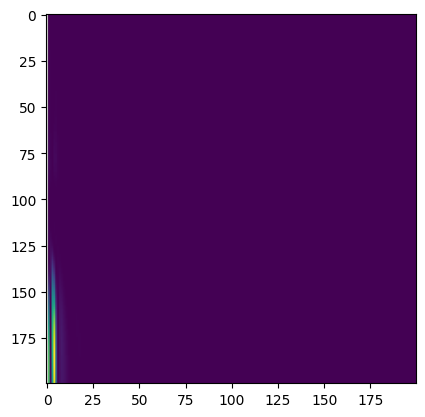

In [81]:
%matplotlib inline
plt.imshow(l)

Average of $u_x$: $1.1762e-02$

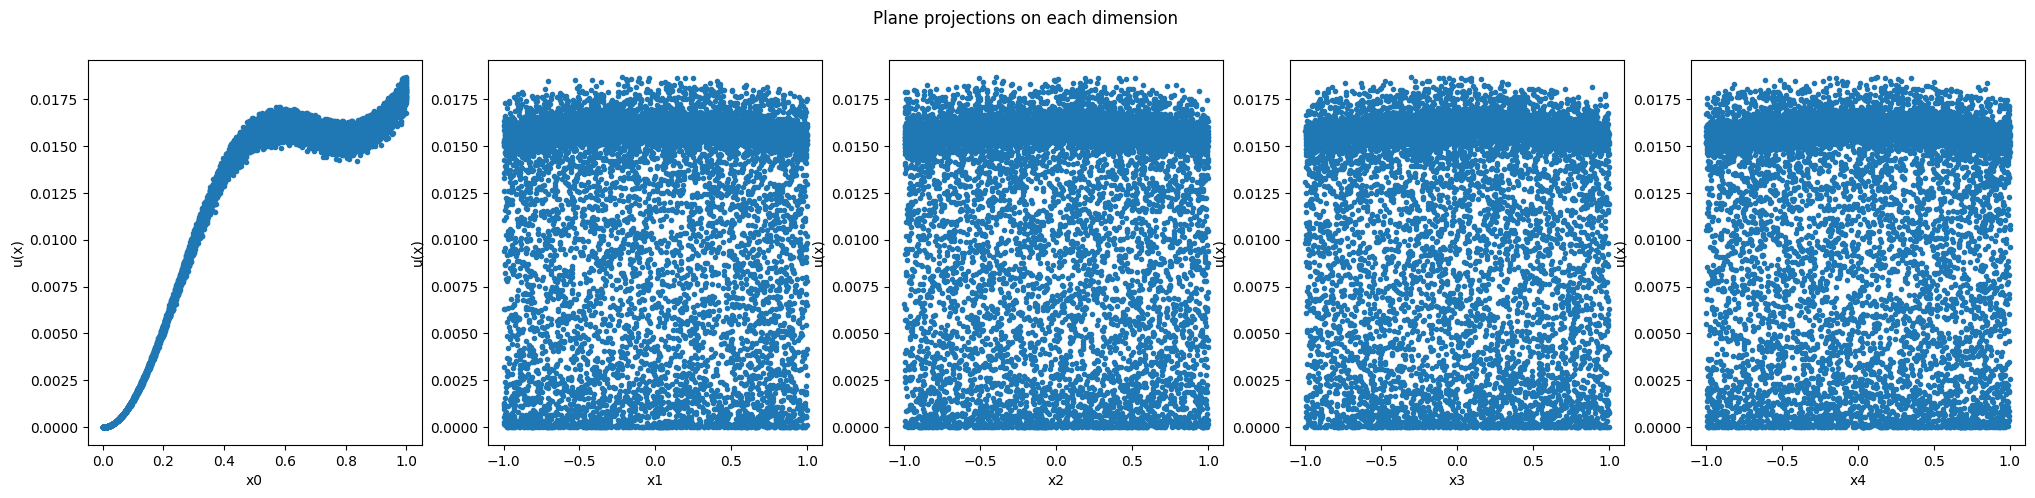

In [82]:
%matplotlib inline
display_solution(b)

Average of $u_x$: $-3.9546e-10$

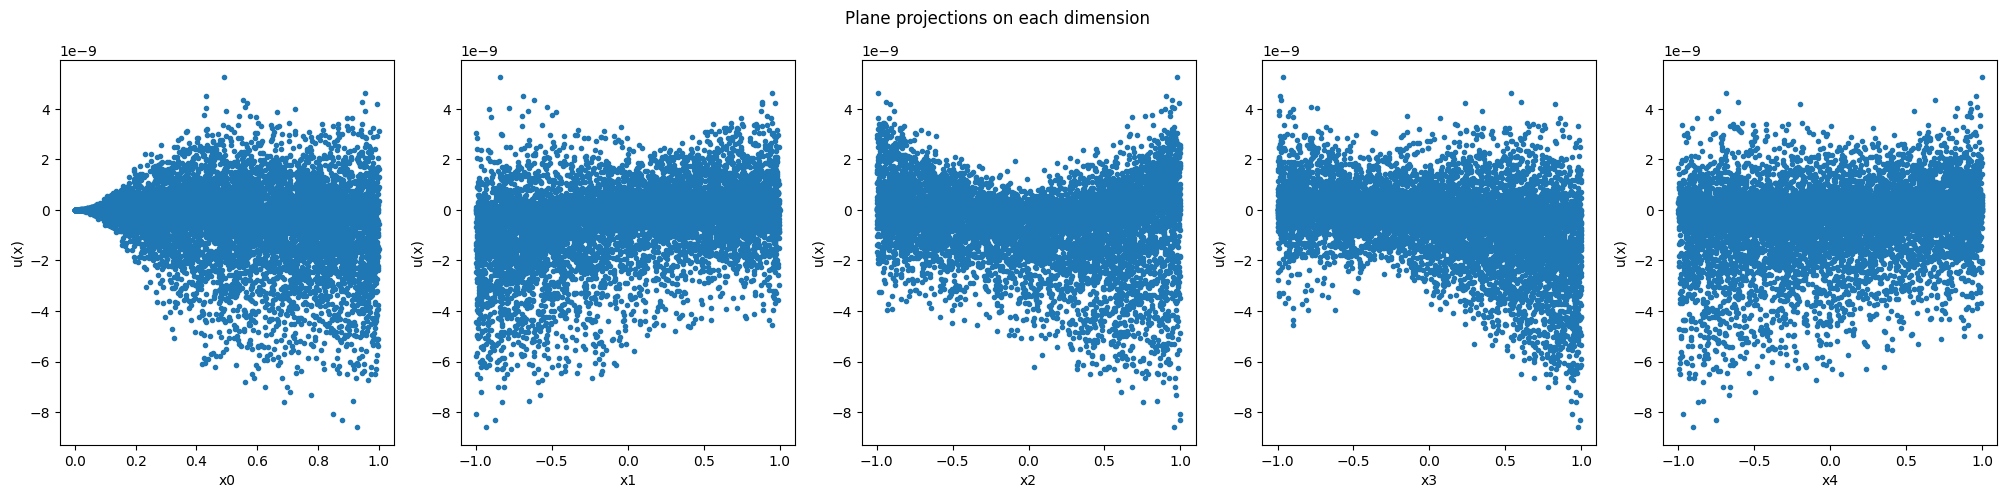

In [83]:
display_solution(n)

In [84]:
%matplotlib inline
x= torch.tensor(2*(np.random.random((100, 5))-0.5))
x[:, 0] = torch.abs(x[:, 0])
x = x.requires_grad_()

mu = 1e2

uxs = []
loss1 = []

for i in tqdm(range(x.shape[0])):
    outputs = n(x[i])
    if outputs.item() != 0:
        loss1.append(np.abs(loss_fn_batch(x[i].unsqueeze(0), outputs, n)[0].item() / outputs.item()))
        uxs.append(outputs)

  0%|          | 0/100 [00:00<?, ?it/s]

In [85]:
loss1 = np.array(loss1)

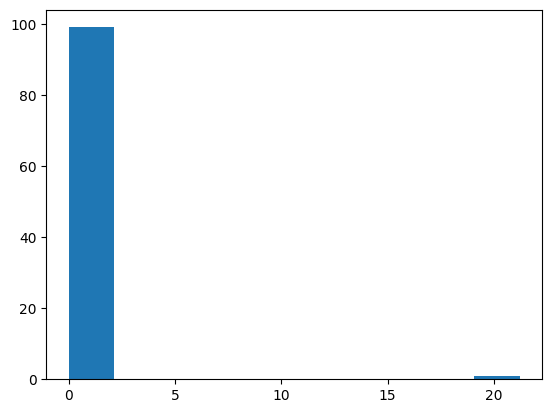

In [86]:
plt.hist(loss1, bins=10)
plt.show()

In [120]:
import sympy as sp

n.eval()
W1 = n.fc1.weight.detach().numpy()
b1 = n.fc1.bias.detach().unsqueeze(-1).numpy()
W2 = n.fc2.weight.detach().numpy()
b2 = n.fc2.bias.detach().unsqueeze(-1).numpy()

x = sp.Matrix(sp.symbols('x0:5'))

fc1_out = sp.Matrix(W1 @ x + b1)
fc1_act = fc1_out.applyfunc(sp.tanh)

fc2_out = sp.Matrix(W2 @ fc1_act + b2)

b_expr = sp.exp(-x[0]**2) 

u = b_expr * fc2_out[0]
u

(4.88181495216316e-7*tanh(-0.27253864186559*x0 + 0.0918797950114043*x1 - 0.211436635931205*x2 + 0.424924087901561*x3 + 0.198793335209171*x4 + 0.239511342717245) + 4.41179653645128e-7*tanh(0.0595433628710433*x0 - 0.316572169622805*x1 + 0.336216790814328*x2 - 0.27171524523359*x3 - 0.289010323300031*x4 + 0.287647961568414) - 3.72738893945814e-7*tanh(0.123695128615807*x0 + 0.203974843289042*x1 - 0.411451918837877*x2 + 0.0691468055900861*x3 + 0.125349600346776*x4 - 0.279765508504819) - 2.22209682694167e-7*tanh(0.234109596812275*x0 + 0.273372965184964*x1 - 0.413337443000614*x2 - 0.242544679429866*x3 + 0.151747977870484*x4 + 0.259083642810834) + 4.50639786646334e-7*tanh(0.288634934700892*x0 + 0.31425077954565*x1 - 0.491502599214503*x2 - 0.0759715552429691*x3 + 0.215844849491774*x4 - 0.0391441394033296) - 2.66491240534642e-7)*exp(-x0**2)

In [122]:
laplacian_u = sum([sp.diff(u, xi, xi) for xi in x])
biharmonic_u = sum([sp.diff(laplacian_u, xi, xi) for xi in x])
rhs = sp.Abs(u)**8 * u

In [ ]:
residual = sp.simplify(biharmonic_u - rhs)
print(residual)